# Residual-Stream Activation Analysis — Emotion × Intensity

Analyzes whether **emotion category** and **emotion intensity** are linearly represented
in the residual stream of a language model.

**Input:** `dataset/activations_emotion_intensity/emotion_intensity_residual_stream.pt`  
Tensor shape: `(N, 8 emotions, 3 intensities, L layers, D hidden)`

---

**Sections:**
1. Load data & inspect
2. Build flat feature matrices per layer
3. PCA visualizations
4. Linear probes (source-id-level split)
5. Emotion vector geometry
6. Intensity direction analysis
7. Emotion vs intensity disentanglement
8. Within-source-mean-subtracted analyses
9. Summary

## 0. Imports & Configuration

In [3]:
from __future__ import annotations

import gc
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT = Path("../..").resolve()
ACT_DIR   = REPO_ROOT / "activation" / "emotion_rewrites"
NPY_PATH  = ACT_DIR / "emotion_intensity_residual_stream.npy"
INFO_PATH = ACT_DIR / "emotion_intensity_residual_stream_info.json"
OUT_DIR   = REPO_ROOT / "analysis" / "emotion_intensity"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Visual style ──────────────────────────────────────────────────────────────
EMO_COLORS = [
    "#e6194b", "#3cb44b", "#4363d8", "#f58231",
    "#911eb4", "#42d4f4", "#f032e6", "#bfef45",
]
INT_COLORS  = {"low": "#4575b4", "medium": "#fdae61", "high": "#d73027"}
INT_MARKERS = {"low": "o",      "medium": "s",       "high": "^"}

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150})
SEED = 42


## 1. Load Data & Inspect

In [4]:
# ── Load metadata ─────────────────────────────────────────────────────────────
with open(INFO_PATH) as f:
    INFO = json.load(f)

LAYER_INDICES:   list[int] = INFO["layer_indices"]
EMOTION_ORDER:   list[str] = INFO["emotion_order"]
INTENSITY_ORDER: list[str] = INFO["intensity_order"]
SOURCE_IDS                 = INFO["source_ids"]
SHAPE                      = tuple(INFO["shape"])   # (N, N_EMO, N_INT, N_LAYERS, D)
DTYPE                      = INFO.get("dtype", "float32")

N, N_EMO, N_INT, N_LAYERS, D = SHAPE

# ── Load activations as memory-mapped array ───────────────────────────────────
act: np.ndarray = np.memmap(str(NPY_PATH), dtype=DTYPE, mode="r", shape=SHAPE)

print(f"Activation tensor shape : {act.shape}")
print(f"Layer indices            : {LAYER_INDICES}")
print(f"Emotions ({N_EMO})         : {EMOTION_ORDER}")
print(f"Intensities ({N_INT})      : {INTENSITY_ORDER}")
print(f"# source texts           : {N}")
print(f"Hidden dim               : {D}")


Activation tensor shape : (22782, 8, 3, 6, 4096)
Layer indices            : [8, 10, 13, 16, 19, 22]
Emotions (8)         : ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
Intensities (3)      : ['low', 'medium', 'high']
# source texts           : 22782
Hidden dim               : 4096


In [5]:
# ── Per-layer statistics (chunked to avoid OOM) ───────────────────────────────
print(f"{'Layer':>6}  {'mean':>10}  {'std':>10}  {'min':>10}  {'max':>10}")
print("-" * 52)
for li, layer in enumerate(LAYER_INDICES):
    r_sum    = np.float64(0.0)
    r_sum_sq = np.float64(0.0)
    r_min    = np.float64(np.inf)
    r_max    = np.float64(-np.inf)
    count    = 0
    for n in range(N):                                   # iterate one source at a time
        chunk = act[n, :, :, li, :].ravel().astype(np.float64)  # (N_EMO*N_INT*D,)
        r_sum    += chunk.sum()
        r_sum_sq += (chunk * chunk).sum()
        r_min     = min(r_min, float(chunk.min()))
        r_max     = max(r_max, float(chunk.max()))
        count    += chunk.size
    mean = r_sum / count
    std  = np.sqrt(max(r_sum_sq / count - mean * mean, 0.0))
    print(f"  {layer:>4}  {mean:>10.4f}  {std:>10.4f}"
          f"  {r_min:>10.4f}  {r_max:>10.4f}")


 Layer        mean         std         min         max
----------------------------------------------------
     8     -0.0011      0.0829     -1.5000      3.4844
    10     -0.0002      0.1033     -1.6094      4.3438
    13     -0.0021      0.1238     -1.6406      4.8125
    16     -0.0029      0.1707     -2.5312      6.0000
    19     -0.0052      0.2417     -6.0625      7.2500
    22     -0.0043      0.3231    -10.8750      7.3125


## 2. Build Flat Feature Matrices per Layer

Flatten `(N, 8, 3, L, D)` to one matrix per layer with shape `(N*8*3, D)`,
and construct parallel label arrays.

In [6]:
import tempfile, os

n_samples = N * N_EMO * N_INT

# ── Use memmap on disk to avoid allocating (N_LAYERS × n_samples × D) in RAM ──
_mmap_path = OUT_DIR / "_X_layers_tmp.mmap"
X_layers = np.memmap(str(_mmap_path), dtype=np.float32, mode="w+",
                     shape=(N_LAYERS, n_samples, D))

y_emotion   = np.empty(n_samples, dtype=np.int8)
y_intensity = np.empty(n_samples, dtype=np.int8)
groups      = np.empty(n_samples, dtype=np.int32)   # source index as group ID

idx = 0
for n in range(N):
    for ei in range(N_EMO):
        for ii in range(N_INT):
            X_layers[:, idx, :] = act[n, ei, ii, :, :]   # (L, D)
            y_emotion[idx]   = ei
            y_intensity[idx] = ii
            groups[idx]      = n
            idx += 1

X_layers.flush()

print(f"X_layers shape     : {X_layers.shape}  (layers × samples × D)  [on-disk memmap]")
print(f"n_samples          : {n_samples}  ({N} × {N_EMO} × {N_INT})")
print(f"Emotion dist       : {np.bincount(y_emotion)}")
print(f"Intensity dist     : {np.bincount(y_intensity)}")
print(f"Groups (source IDs): {groups.min()} – {groups.max()} ({len(np.unique(groups))} unique)")


X_layers shape     : (6, 546768, 4096)  (layers × samples × D)  [on-disk memmap]
n_samples          : 546768  (22782 × 8 × 3)
Emotion dist       : [68346 68346 68346 68346 68346 68346 68346 68346]
Intensity dist     : [182256 182256 182256]
Groups (source IDs): 0 – 22781 (22782 unique)


## 3. PCA Visualizations

Run PCA to 2-D on each layer. Plot:
- (a) coloured by **emotion**
- (b) coloured by **intensity**
- (c) a small random subset coloured by **source_id**

In [7]:
# ── Fit PCA per layer ─────────────────────────────────────────────────────────
# Use a subsample for speed if dataset is large.
MAX_PCA = min(n_samples, 5000)
rng = np.random.default_rng(SEED)
pca_idx = rng.choice(n_samples, size=MAX_PCA, replace=False)

layer_pcas   = []
layer_coords = []

for li in range(N_LAYERS):
    X = X_layers[li][pca_idx]                # (MAX_PCA, D)
    pca = PCA(n_components=2, random_state=SEED)
    coords = pca.fit_transform(X)
    layer_pcas.append(pca)
    layer_coords.append(coords)

y_emo_sub = y_emotion[pca_idx]
y_int_sub = y_intensity[pca_idx]
grp_sub   = groups[pca_idx]

print("PCA fitting done.")

PCA fitting done.


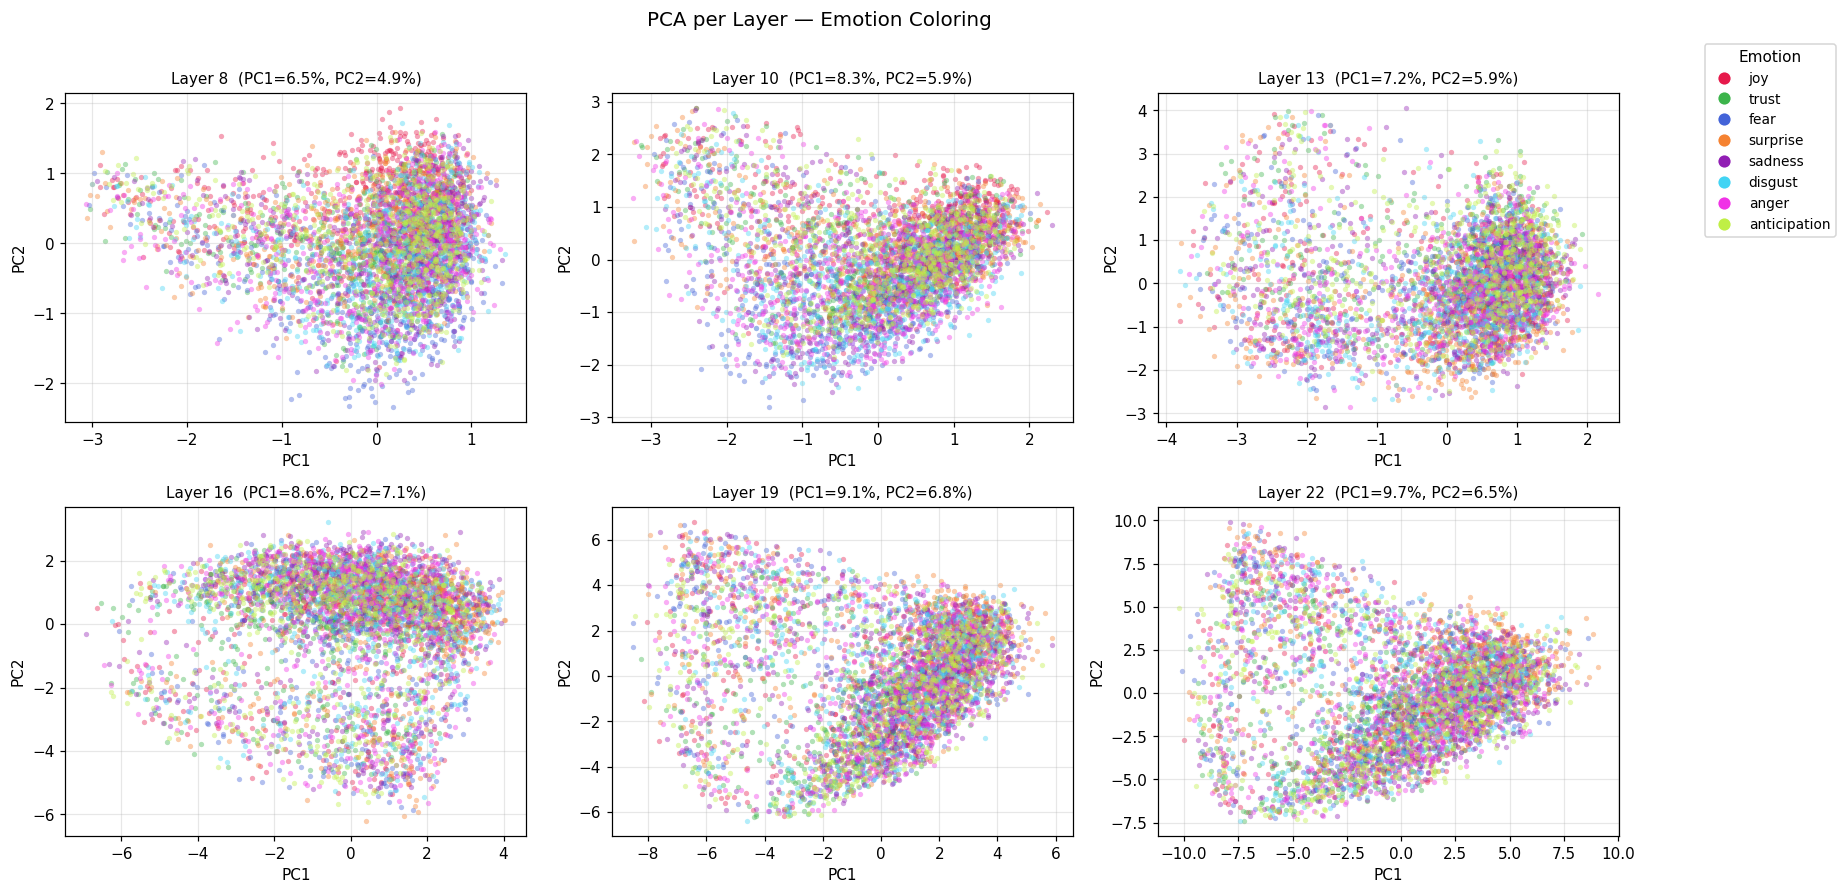

In [8]:
# ── (a) Emotion coloring ──────────────────────────────────────────────────────
ncols = 3
nrows = int(np.ceil(N_LAYERS / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).ravel()

for li in range(N_LAYERS):
    ax = axes[li]
    coords = layer_coords[li]
    evr = layer_pcas[li].explained_variance_ratio_
    for ei, emo in enumerate(EMOTION_ORDER):
        mask = y_emo_sub == ei
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=EMO_COLORS[ei], label=emo,
                   s=12, alpha=0.4, linewidths=0, rasterized=True)
    ax.set_title(f"Layer {LAYER_INDICES[li]}  (PC1={evr[0]:.1%}, PC2={evr[1]:.1%})", fontsize=10)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

for ax in axes[N_LAYERS:]:
    ax.set_visible(False)

handles = [plt.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=EMO_COLORS[ei], markersize=9, label=emo)
           for ei, emo in enumerate(EMOTION_ORDER)]
fig.legend(handles=handles, title="Emotion", loc="upper right",
           bbox_to_anchor=(1.12, 0.98), fontsize=9)
fig.suptitle("PCA per Layer — Emotion Coloring", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / "pca_emotion_coloring.png", bbox_inches="tight")
plt.show()

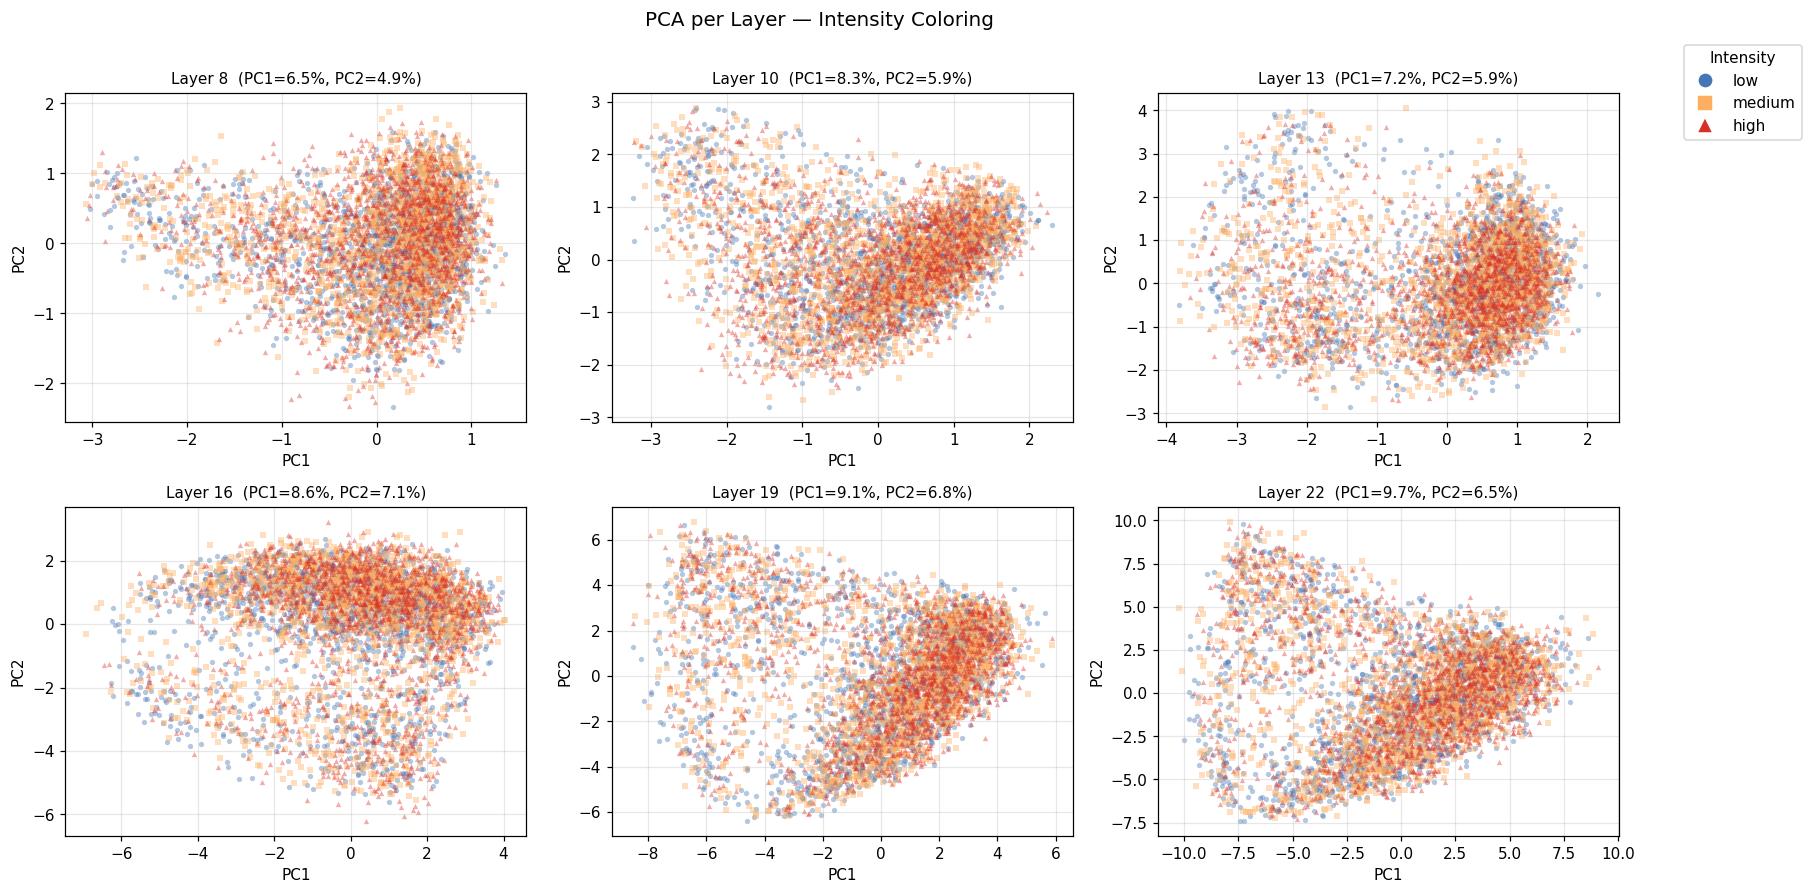

In [9]:
# ── (b) Intensity coloring ────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).ravel()

for li in range(N_LAYERS):
    ax = axes[li]
    coords = layer_coords[li]
    evr = layer_pcas[li].explained_variance_ratio_
    for ii, intens in enumerate(INTENSITY_ORDER):
        mask = y_int_sub == ii
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   color=INT_COLORS[intens], marker=INT_MARKERS[intens],
                   label=intens, s=12, alpha=0.4, linewidths=0, rasterized=True)
    ax.set_title(f"Layer {LAYER_INDICES[li]}  (PC1={evr[0]:.1%}, PC2={evr[1]:.1%})", fontsize=10)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

for ax in axes[N_LAYERS:]:
    ax.set_visible(False)

handles = [plt.Line2D([0], [0], marker=INT_MARKERS[intens], color="w",
                      markerfacecolor=INT_COLORS[intens], markersize=10, label=intens)
           for intens in INTENSITY_ORDER]
fig.legend(handles=handles, title="Intensity", loc="upper right",
           bbox_to_anchor=(1.10, 0.98), fontsize=10)
fig.suptitle("PCA per Layer — Intensity Coloring", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / "pca_intensity_coloring.png", bbox_inches="tight")
plt.show()

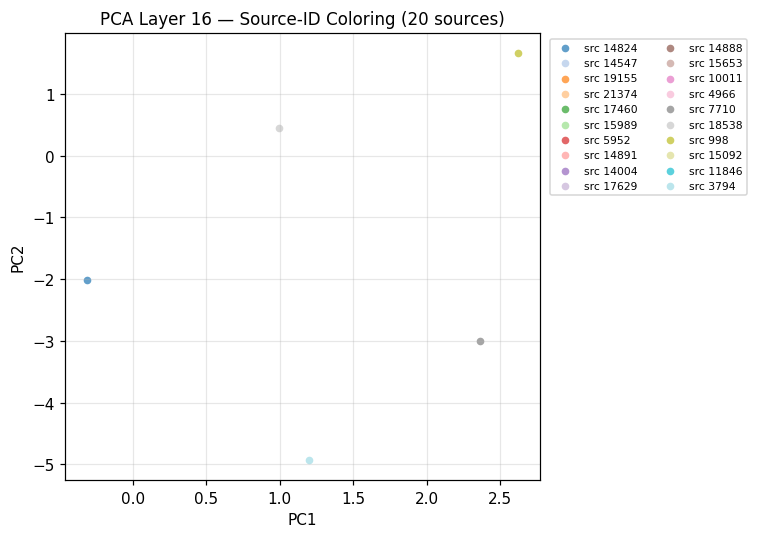

In [10]:
# ── (c) Source-id coloring — random subset of 20 sources ─────────────────────
N_SRC_SHOW = min(20, N)
chosen_srcs = rng.choice(N, size=N_SRC_SHOW, replace=False)
src_mask    = np.isin(grp_sub, chosen_srcs)
src_palette = plt.cm.tab20(np.linspace(0, 1, N_SRC_SHOW))
src_colormap = {s: src_palette[i] for i, s in enumerate(chosen_srcs)}

# Pick best-performing layer for this plot (use middle layer as default)
li_show = N_LAYERS // 2

fig, ax = plt.subplots(figsize=(7, 5))
coords = layer_coords[li_show]
for src in chosen_srcs:
    m = src_mask & (grp_sub == src)
    ax.scatter(coords[m, 0], coords[m, 1],
               color=src_colormap[src], label=f"src {src}",
               s=25, alpha=0.7, linewidths=0)
ax.set_title(f"PCA Layer {LAYER_INDICES[li_show]} — Source-ID Coloring ({N_SRC_SHOW} sources)",
             fontsize=11)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
fig.savefig(OUT_DIR / "pca_source_coloring.png", bbox_inches="tight")
plt.show()

## 4. Linear Probes — Source-ID-Level Split

`GroupShuffleSplit` ensures no source text appears in both train and test.
Reports accuracy, balanced accuracy, and macro-F1 per layer.

In [11]:
def run_probe(
    X: np.ndarray,
    y: np.ndarray,
    grps: np.ndarray,
    test_size: float = 0.2,
    max_samples: int = 20_000,   # cap to avoid OOM (full set is ~547 K rows × 4096 × float64 ≈ 13 GB)
) -> dict:
    """
    Train a RidgeClassifier with a source-ID-level split.
    Subsamples to max_samples before fitting to keep RAM usage manageable.
    Returns a dict with accuracy, balanced_accuracy, macro-f1, clf, y_te, y_pred.
    """
    from sklearn.metrics import f1_score

    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=SEED)
    train_idx, test_idx = next(gss.split(X, y, grps))

    # Sub-sample each split — a linear probe on D=4096 converges well within 20 K points
    rng_sub = np.random.default_rng(SEED)
    max_tr = int(max_samples * (1 - test_size))
    max_te = max_samples - max_tr
    if len(train_idx) > max_tr:
        train_idx = rng_sub.choice(train_idx, size=max_tr, replace=False)
    if len(test_idx) > max_te:
        test_idx = rng_sub.choice(test_idx, size=max_te, replace=False)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X[train_idx].astype(np.float64))
    y_tr = y[train_idx]

    clf = RidgeClassifier(alpha=1.0)
    clf.fit(X_tr, y_tr)
    del X_tr   # free ~500 MB training matrix before allocating test data

    X_te = scaler.transform(X[test_idx].astype(np.float64))
    y_te = y[test_idx]
    y_pred = clf.predict(X_te)
    del X_te

    return {
        "acc":      accuracy_score(y_te, y_pred),
        "bal_acc":  balanced_accuracy_score(y_te, y_pred),
        "f1":       f1_score(y_te, y_pred, average="macro"),
        "clf":      clf,
        "scaler":   scaler,
        "y_te":     y_te,
        "y_pred":   y_pred,
    }


print("Running emotion probes ...")
emo_probes = {}
for li in range(N_LAYERS):
    emo_probes[li] = run_probe(X_layers[li], y_emotion, groups)
    r = emo_probes[li]
    print(f"  Layer {LAYER_INDICES[li]:>2}  acc={r['acc']:.3f}  "
          f"bal_acc={r['bal_acc']:.3f}  macro-F1={r['f1']:.3f}")
    gc.collect()

print()
print("Running intensity probes ...")
int_probes = {}
for li in range(N_LAYERS):
    int_probes[li] = run_probe(X_layers[li], y_intensity, groups)
    r = int_probes[li]
    print(f"  Layer {LAYER_INDICES[li]:>2}  acc={r['acc']:.3f}  "
          f"bal_acc={r['bal_acc']:.3f}  macro-F1={r['f1']:.3f}")
    gc.collect()


Running emotion probes ...
  Layer  8  acc=0.807  bal_acc=0.809  macro-F1=0.808
  Layer 10  acc=0.812  bal_acc=0.813  macro-F1=0.812
  Layer 13  acc=0.816  bal_acc=0.817  macro-F1=0.816
  Layer 16  acc=0.785  bal_acc=0.787  macro-F1=0.786
  Layer 19  acc=0.751  bal_acc=0.753  macro-F1=0.752
  Layer 22  acc=0.723  bal_acc=0.724  macro-F1=0.723

Running intensity probes ...
  Layer  8  acc=0.638  bal_acc=0.636  macro-F1=0.634
  Layer 10  acc=0.635  bal_acc=0.633  macro-F1=0.631
  Layer 13  acc=0.641  bal_acc=0.639  macro-F1=0.637
  Layer 16  acc=0.630  bal_acc=0.629  macro-F1=0.626
  Layer 19  acc=0.601  bal_acc=0.599  macro-F1=0.596
  Layer 22  acc=0.602  bal_acc=0.600  macro-F1=0.597


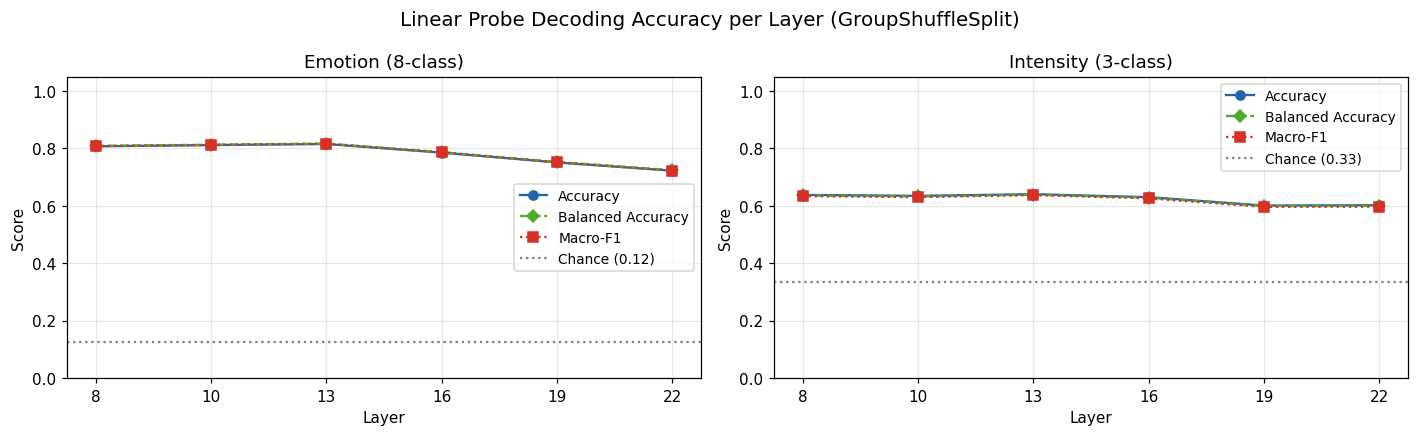

 layer      task     acc  bal_acc       f1
     8   emotion 0.80750 0.809149 0.808062
     8 intensity 0.63825 0.636329 0.633991
    10   emotion 0.81175 0.813055 0.812274
    10 intensity 0.63500 0.632969 0.630586
    13   emotion 0.81550 0.817082 0.816463
    13 intensity 0.64075 0.638917 0.637487
    16   emotion 0.78550 0.787244 0.786029
    16 intensity 0.63050 0.628609 0.626361
    19   emotion 0.75125 0.752920 0.751683
    19 intensity 0.60125 0.599237 0.596378
    22   emotion 0.72250 0.724495 0.723034
    22 intensity 0.60225 0.600117 0.597192


In [12]:
# ── Probe accuracy plot across layers ─────────────────────────────────────────
layer_labels = [str(l) for l in LAYER_INDICES]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, probes, title, chance in [
    (axes[0], emo_probes, "Emotion (8-class)", 1 / 8),
    (axes[1], int_probes, "Intensity (3-class)", 1 / 3),
]:
    accs  = [probes[li]["acc"]     for li in range(N_LAYERS)]
    bals  = [probes[li]["bal_acc"] for li in range(N_LAYERS)]
    f1s   = [probes[li]["f1"]      for li in range(N_LAYERS)]
    ax.plot(layer_labels, accs,  "o-",  label="Accuracy",           color="#2166ac")
    ax.plot(layer_labels, bals,  "D--", label="Balanced Accuracy",   color="#4dac26")
    ax.plot(layer_labels, f1s,   "s:",  label="Macro-F1",            color="#d73027")
    ax.axhline(chance, color="gray", linestyle=":", label=f"Chance ({chance:.2f})")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Linear Probe Decoding Accuracy per Layer (GroupShuffleSplit)", fontsize=13)
plt.tight_layout()
fig.savefig(OUT_DIR / "probe_accuracy_by_layer.png", bbox_inches="tight")
plt.show()

# ── Save CSV ──────────────────────────────────────────────────────────────────
rows = []
for li in range(N_LAYERS):
    for label, probes in [("emotion", emo_probes), ("intensity", int_probes)]:
        r = probes[li]
        rows.append({"layer": LAYER_INDICES[li], "task": label,
                     "acc": r["acc"], "bal_acc": r["bal_acc"], "f1": r["f1"]})
probe_df = pd.DataFrame(rows)
probe_df.to_csv(OUT_DIR / "probe_results.csv", index=False)
print(probe_df.to_string(index=False))

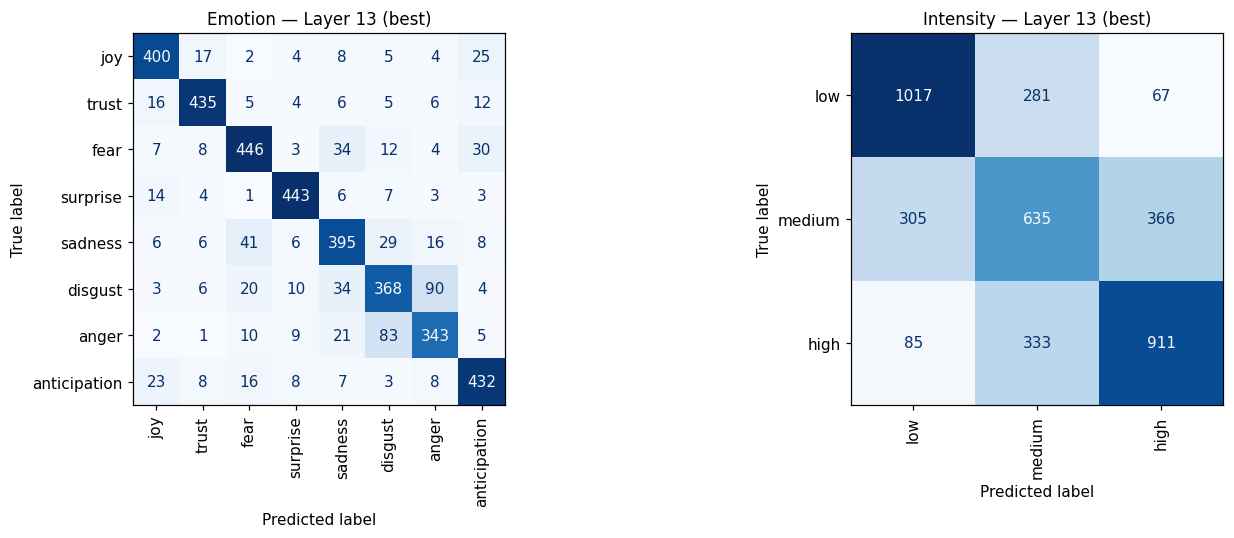


Best layer for emotion  : 13
Best layer for intensity: 13

=== Emotion classification report ===
              precision    recall  f1-score   support

         joy      0.849     0.860     0.855       465
       trust      0.897     0.890     0.893       489
        fear      0.824     0.820     0.822       544
    surprise      0.910     0.921     0.915       481
     sadness      0.773     0.779     0.776       507
     disgust      0.719     0.688     0.703       535
       anger      0.724     0.724     0.724       474
anticipation      0.832     0.855     0.844       505

    accuracy                          0.816      4000
   macro avg      0.816     0.817     0.816      4000
weighted avg      0.815     0.816     0.815      4000

=== Intensity classification report ===
              precision    recall  f1-score   support

         low      0.723     0.745     0.734      1365
      medium      0.508     0.486     0.497      1306
        high      0.678     0.685     0.682     

In [13]:
# ── Confusion matrices for best layers ────────────────────────────────────────
best_emo_li  = max(emo_probes, key=lambda li: emo_probes[li]["bal_acc"])
best_int_li  = max(int_probes, key=lambda li: int_probes[li]["bal_acc"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, li, probes, names, title_prefix in [
    (axes[0], best_emo_li,  emo_probes, EMOTION_ORDER,   "Emotion"),
    (axes[1], best_int_li,  int_probes, INTENSITY_ORDER, "Intensity"),
]:
    cm = confusion_matrix(probes[li]["y_te"], probes[li]["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", xticks_rotation="vertical")
    ax.set_title(f"{title_prefix} — Layer {LAYER_INDICES[li]} (best)", fontsize=11)

plt.tight_layout()
fig.savefig(OUT_DIR / "confusion_matrices_best_layer.png", bbox_inches="tight")
plt.show()

print(f"\nBest layer for emotion  : {LAYER_INDICES[best_emo_li]}")
print(f"Best layer for intensity: {LAYER_INDICES[best_int_li]}")
print()
print("=== Emotion classification report ===")
print(classification_report(emo_probes[best_emo_li]["y_te"],
                             emo_probes[best_emo_li]["y_pred"],
                             target_names=EMOTION_ORDER, digits=3))
print("=== Intensity classification report ===")
print(classification_report(int_probes[best_int_li]["y_te"],
                             int_probes[best_int_li]["y_pred"],
                             target_names=INTENSITY_ORDER, digits=3))

## 5. Emotion Vector Geometry

One-vs-rest emotion vector:
$$\mathbf{v}_e = \bar{\mathbf{h}}_{e} - \overline{\mathbf{h}}_{\neg e}$$

Plot cosine-similarity heatmaps and selected pairwise cosines by layer.

In [14]:
def cosine_sim_matrix(vecs: np.ndarray) -> np.ndarray:
    """vecs: (K, D) → (K, K) cosine similarity matrix."""
    norms  = np.linalg.norm(vecs, axis=1, keepdims=True)
    norms  = np.where(norms == 0, 1e-10, norms)
    normed = vecs / norms
    return normed @ normed.T


# ── Compute prototype means (chunked over N to avoid loading full act) ────────
# proto[e, i, li, :] = mean over N sources
proto_sum = np.zeros((N_EMO, N_INT, N_LAYERS, D), dtype=np.float64)
for n in range(N):
    proto_sum += act[n].astype(np.float64)   # (N_EMO, N_INT, N_LAYERS, D)
proto = (proto_sum / N).astype(np.float32)
del proto_sum

# OvR emotion vectors: mean(e) − mean(not e), averaged over intensity
emo_mean  = proto.mean(axis=1)   # (N_EMO, N_LAYERS, D)  mean over intensity
grand_mean = emo_mean.mean(axis=0, keepdims=True)  # (1, N_LAYERS, D)
emo_ovr   = emo_mean - (emo_mean.sum(axis=0, keepdims=True) - emo_mean) / (N_EMO - 1)

print(f"proto shape   : {proto.shape}")
print(f"emo_mean shape: {emo_mean.shape}")
print(f"emo_ovr shape : {emo_ovr.shape}")


proto shape   : (8, 3, 6, 4096)
emo_mean shape: (8, 6, 4096)
emo_ovr shape : (8, 6, 4096)


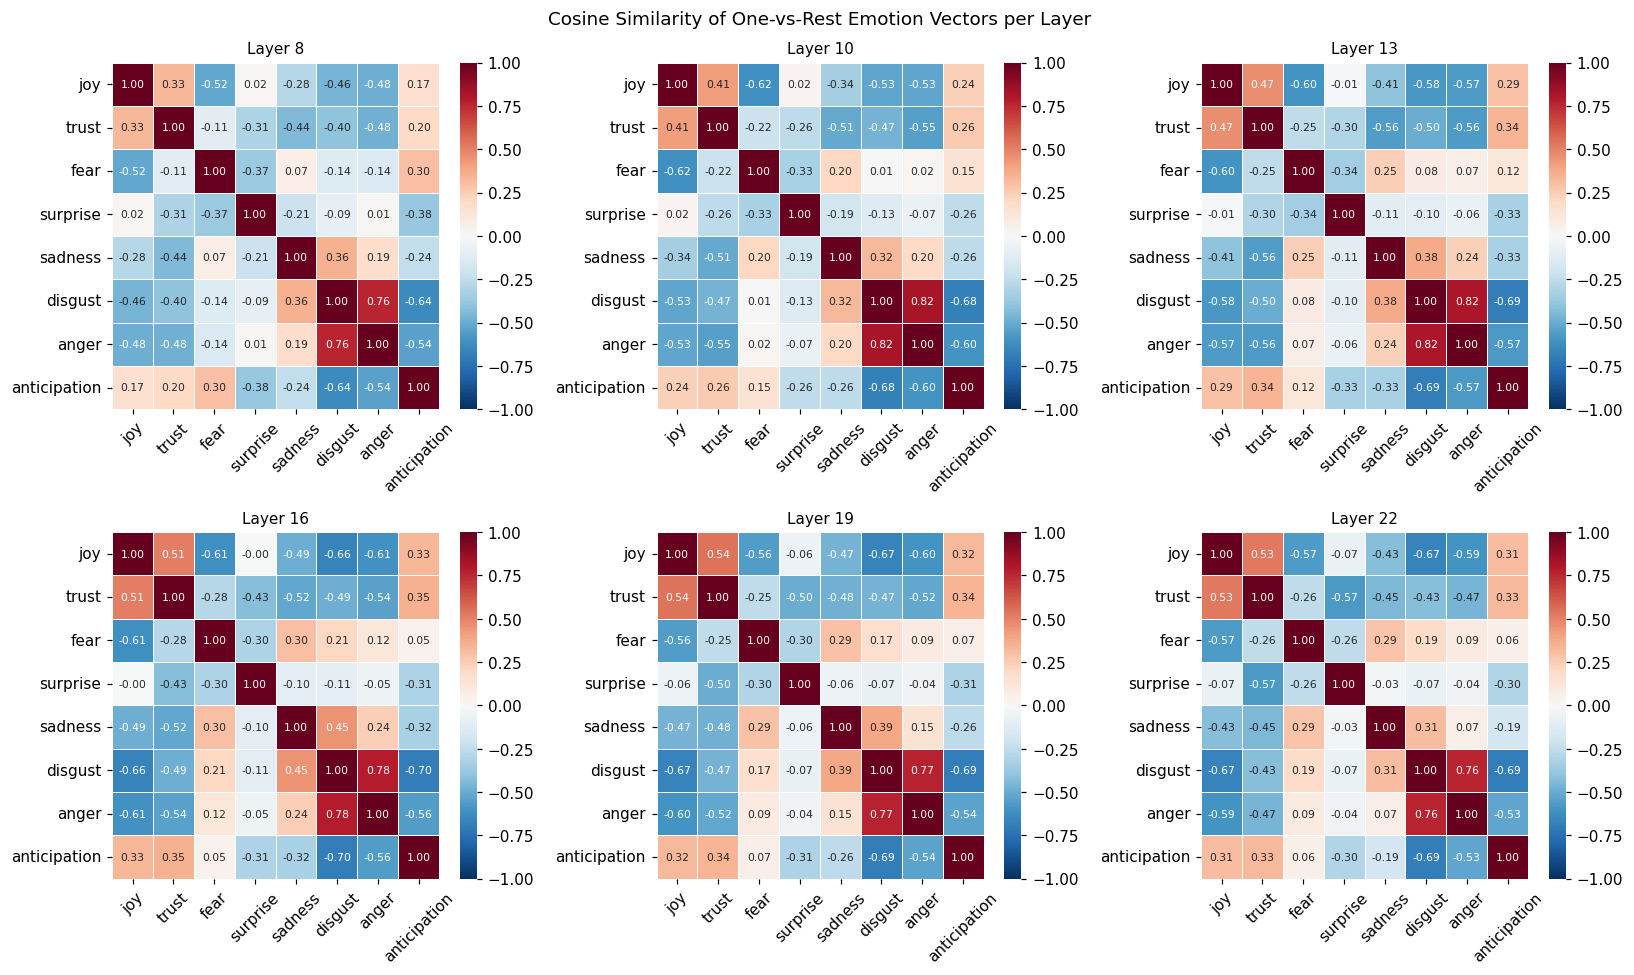

In [15]:
# ── Cosine-similarity heatmaps ────────────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.array(axes).ravel()

for li in range(N_LAYERS):
    ax = axes[li]
    V  = emo_ovr[:, li, :].astype(np.float64)   # (N_EMO, D)
    CS = cosine_sim_matrix(V)
    sns.heatmap(CS, ax=ax,
                xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER,
                vmin=-1, vmax=1, cmap="RdBu_r",
                annot=True, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.4)
    ax.set_title(f"Layer {LAYER_INDICES[li]}", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

for ax in axes[N_LAYERS:]:
    ax.set_visible(False)

fig.suptitle("Cosine Similarity of One-vs-Rest Emotion Vectors per Layer", fontsize=12)
plt.tight_layout()
fig.savefig(OUT_DIR / "emotion_vector_cosine_heatmap.png", bbox_inches="tight")
plt.show()

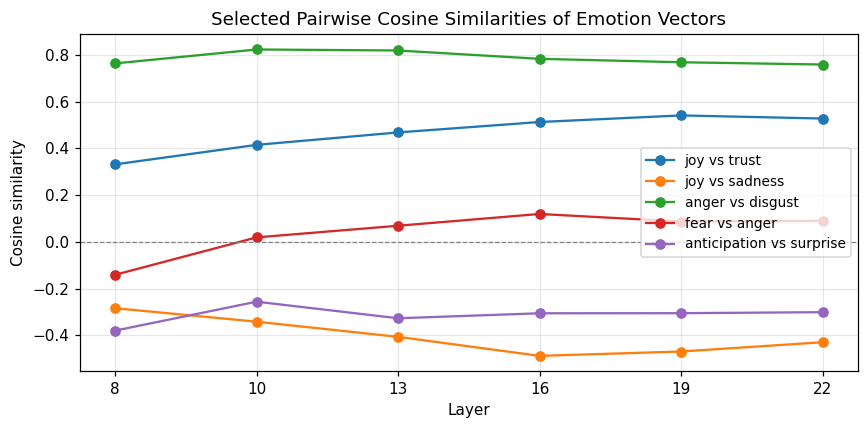

       joy_vs_trust  joy_vs_sadness  anger_vs_disgust  fear_vs_anger  anticipation_vs_surprise
layer                                                                                         
8            0.3313         -0.2838            0.7630        -0.1408                   -0.3796
10           0.4148         -0.3414            0.8227         0.0191                   -0.2559
13           0.4679         -0.4062            0.8184         0.0690                   -0.3268
16           0.5125         -0.4876            0.7827         0.1192                   -0.3054
19           0.5407         -0.4689            0.7681         0.0869                   -0.3050
22           0.5274         -0.4292            0.7584         0.0899                   -0.3007


In [16]:
# ── Selected pairwise cosines by layer ───────────────────────────────────────
PAIRS = [
    ("joy",          "trust"),
    ("joy",          "sadness"),
    ("anger",        "disgust"),
    ("fear",         "anger"),
    ("anticipation", "surprise"),
]

pair_cosines: dict[tuple, list] = {p: [] for p in PAIRS}

for li in range(N_LAYERS):
    V = emo_ovr[:, li, :].astype(np.float64)
    norms  = np.linalg.norm(V, axis=1, keepdims=True)
    norms  = np.where(norms == 0, 1e-10, norms)
    V_norm = V / norms
    for ea, eb in PAIRS:
        ia = EMOTION_ORDER.index(ea)
        ib = EMOTION_ORDER.index(eb)
        pair_cosines[(ea, eb)].append(float(V_norm[ia] @ V_norm[ib]))

fig, ax = plt.subplots(figsize=(8, 4))
for (ea, eb), values in pair_cosines.items():
    ax.plot(layer_labels, values, "o-", label=f"{ea} vs {eb}")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Layer"); ax.set_ylabel("Cosine similarity")
ax.set_title("Selected Pairwise Cosine Similarities of Emotion Vectors", fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "emotion_pairwise_cosines.png", bbox_inches="tight")
plt.show()

# Save CSV
pair_df = pd.DataFrame(
    {f"{ea}_vs_{eb}": v for (ea, eb), v in pair_cosines.items()},
    index=LAYER_INDICES
)
pair_df.index.name = "layer"
pair_df.to_csv(OUT_DIR / "emotion_pairwise_cosines.csv")
print(pair_df.round(4).to_string())

## 6. Intensity Direction Analysis

**Global intensity vector:** $\mathbf{v}_{\text{int}} = \bar{\mathbf{h}}_{\text{high}} - \bar{\mathbf{h}}_{\text{low}}$  
**Emotion-specific:** $\mathbf{v}_{\text{int},e} = \bar{\mathbf{h}}_{e,\text{high}} - \bar{\mathbf{h}}_{e,\text{low}}$

Checks:
- Are emotion-specific intensity vectors near-parallel?
- Does projecting onto $\mathbf{v}_{\text{int}}$ give a monotonic low < medium < high ordering?

In [17]:
HIGH_IDX = INTENSITY_ORDER.index("high")
MED_IDX  = INTENSITY_ORDER.index("medium")
LOW_IDX  = INTENSITY_ORDER.index("low")

# intensity_dirs[e, li, :] = high − low prototype
intensity_dirs = (proto[:, HIGH_IDX, :, :] - proto[:, LOW_IDX, :, :])  # (N_EMO, N_LAYERS, D)

# Global intensity vector: average over emotions
global_int_vec = intensity_dirs.mean(axis=0)   # (N_LAYERS, D)

print(f"intensity_dirs shape  : {intensity_dirs.shape}")
print(f"global_int_vec shape  : {global_int_vec.shape}")

intensity_dirs shape  : (8, 6, 4096)
global_int_vec shape  : (6, 4096)


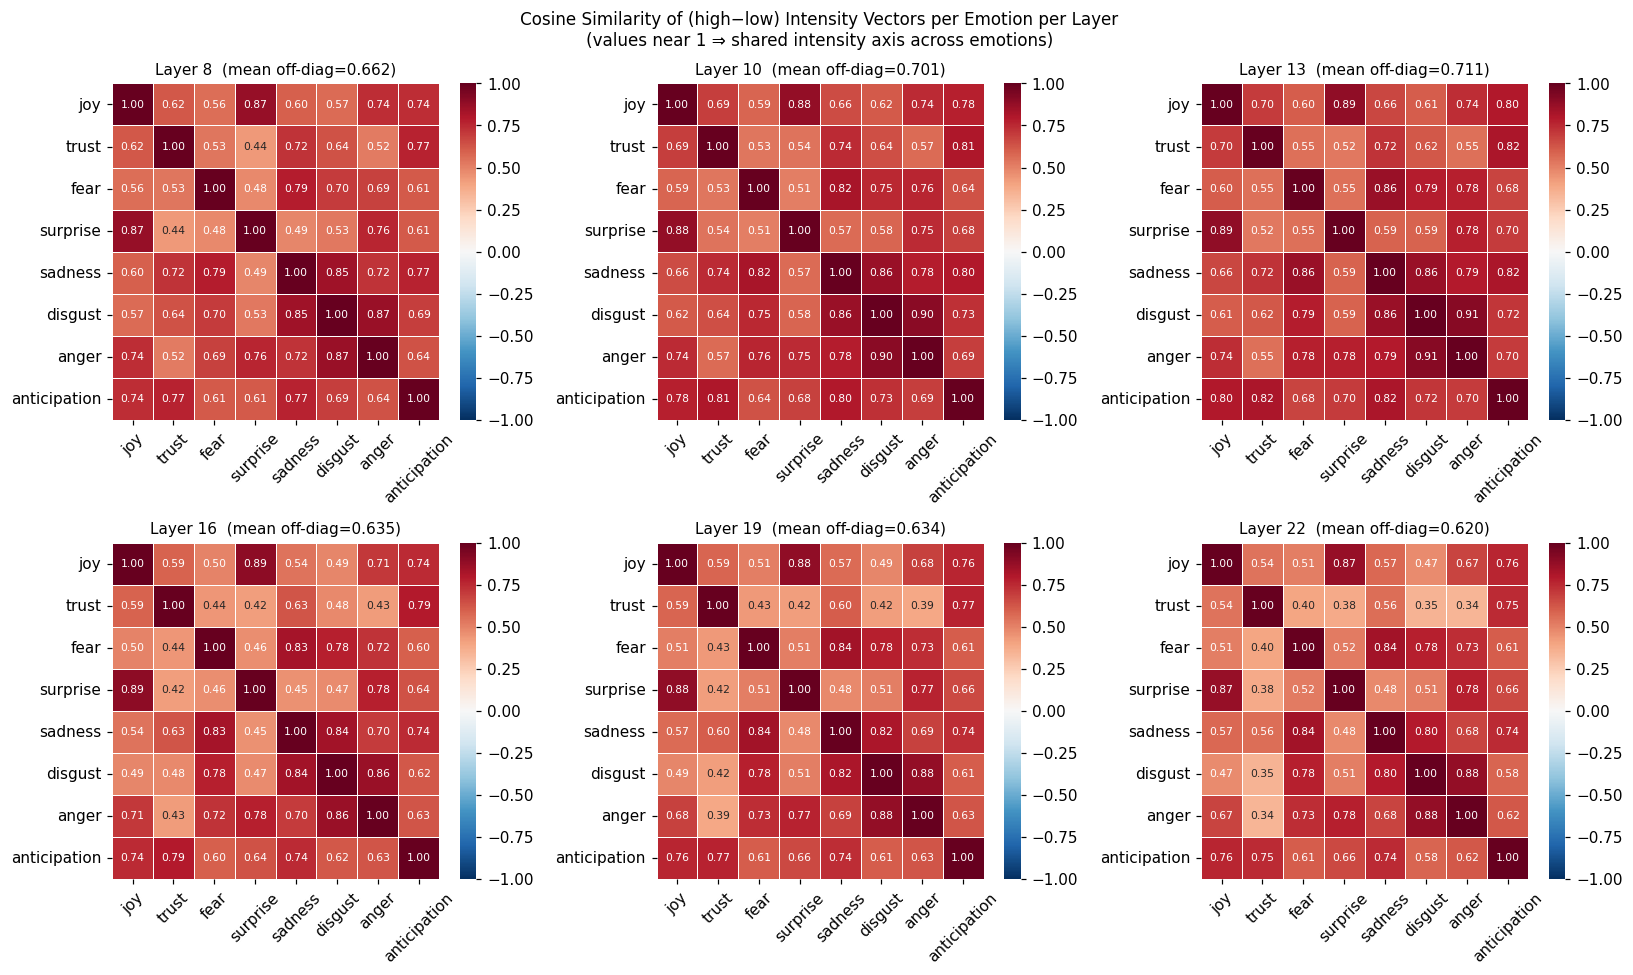

In [18]:
# ── (a) Pairwise cosine similarity heatmaps of emotion-specific intensity dirs ─
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.array(axes).ravel()
mean_off_diag = []

for li in range(N_LAYERS):
    ax = axes[li]
    D_vecs = intensity_dirs[:, li, :].astype(np.float64)   # (N_EMO, D)
    CS = cosine_sim_matrix(D_vecs)
    mask_upper = np.triu(np.ones_like(CS, dtype=bool), k=1)
    mu = CS[mask_upper].mean()
    mean_off_diag.append(mu)

    sns.heatmap(CS, ax=ax,
                xticklabels=EMOTION_ORDER, yticklabels=EMOTION_ORDER,
                vmin=-1, vmax=1, cmap="RdBu_r",
                annot=True, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.4)
    ax.set_title(f"Layer {LAYER_INDICES[li]}  (mean off-diag={mu:.3f})", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

for ax in axes[N_LAYERS:]:
    ax.set_visible(False)

fig.suptitle(
    "Cosine Similarity of (high−low) Intensity Vectors per Emotion per Layer\n"
    "(values near 1 ⇒ shared intensity axis across emotions)",
    fontsize=11)
plt.tight_layout()
fig.savefig(OUT_DIR / "intensity_dir_cosine_heatmap.png", bbox_inches="tight")
plt.show()

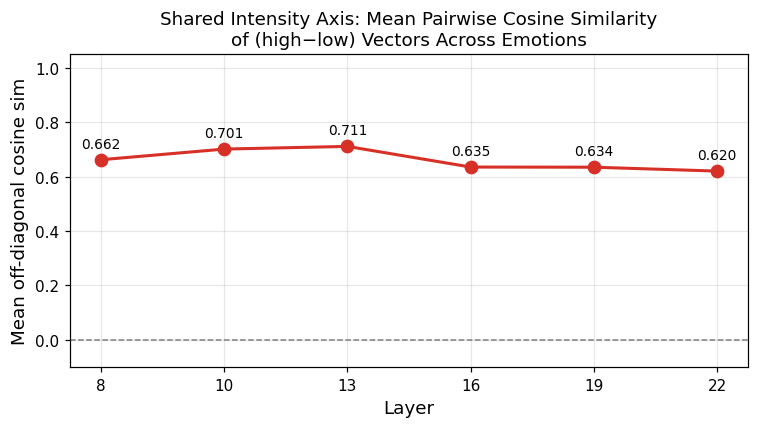

Mean off-diagonal cosine similarity per layer:
  Layer  8: 0.6617
  Layer 10: 0.7008
  Layer 13: 0.7106
  Layer 16: 0.6348
  Layer 19: 0.6343
  Layer 22: 0.6200


In [19]:
# ── (b) Mean off-diagonal cosine similarity per layer ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(layer_labels, mean_off_diag, "o-", color="#d73027", linewidth=2, markersize=8)
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
for x, y in zip(layer_labels, mean_off_diag):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)
ax.set_xlabel("Layer", fontsize=12); ax.set_ylabel("Mean off-diagonal cosine sim", fontsize=12)
ax.set_title("Shared Intensity Axis: Mean Pairwise Cosine Similarity\nof (high−low) Vectors Across Emotions", fontsize=12)
ax.set_ylim(-0.1, 1.05); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "intensity_shared_axis.png", bbox_inches="tight")
plt.show()

print("Mean off-diagonal cosine similarity per layer:")
for li, mu in enumerate(mean_off_diag):
    print(f"  Layer {LAYER_INDICES[li]:>2}: {mu:.4f}")

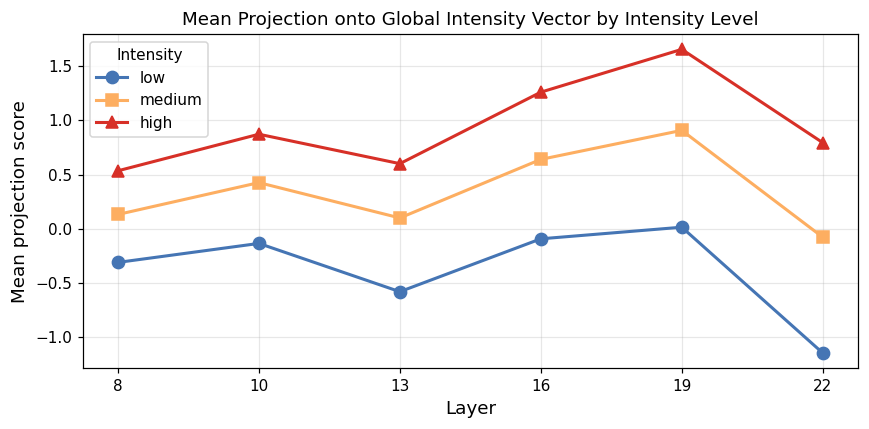

Monotonicity check (low < medium < high)?
  Layer  8: ✓  low=-0.3097  medium=+0.1324  high=+0.5350
  Layer 10: ✓  low=-0.1346  medium=+0.4261  high=+0.8722
  Layer 13: ✓  low=-0.5797  medium=+0.1002  high=+0.6008
  Layer 16: ✓  low=-0.0921  medium=+0.6401  high=+1.2599
  Layer 19: ✓  low=+0.0149  medium=+0.9078  high=+1.6547
  Layer 22: ✓  low=-1.1450  medium=-0.0773  high=+0.7942


In [20]:
# ── (c) Monotonicity check: projection onto global intensity vector ────────────
# proj[e, i, li] = proto[e, i, li] · v_int[li] / ||v_int[li]||
v_norm  = global_int_vec / (np.linalg.norm(global_int_vec, axis=1, keepdims=True) + 1e-10)  # (L, D)

proj = np.einsum("eild,ld->eil", proto.astype(np.float64), v_norm.astype(np.float64))
# proj shape: (N_EMO, N_INT, N_LAYERS)

# Mean over emotions for each (intensity, layer)
mean_proj = proj.mean(axis=0)   # (N_INT, N_LAYERS)

fig, ax = plt.subplots(figsize=(8, 4))
for ii, intens in enumerate(INTENSITY_ORDER):
    ax.plot(layer_labels, mean_proj[ii], "o-",
            color=INT_COLORS[intens], marker=INT_MARKERS[intens],
            label=intens, linewidth=2, markersize=8)
ax.set_xlabel("Layer", fontsize=12); ax.set_ylabel("Mean projection score", fontsize=12)
ax.set_title("Mean Projection onto Global Intensity Vector by Intensity Level", fontsize=12)
ax.legend(title="Intensity"); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / "intensity_projection_monotonicity.png", bbox_inches="tight")
plt.show()

# Check monotonicity per layer
print("Monotonicity check (low < medium < high)?")
for li in range(N_LAYERS):
    vals = mean_proj[:, li]
    order = "✓" if vals[LOW_IDX] < vals[MED_IDX] < vals[HIGH_IDX] else "✗"
    print(f"  Layer {LAYER_INDICES[li]:>2}: {order}  "
          f"low={vals[LOW_IDX]:+.4f}  medium={vals[MED_IDX]:+.4f}  high={vals[HIGH_IDX]:+.4f}")

## 7. Emotion vs Intensity Disentanglement

Cosine similarity between each **one-vs-rest emotion vector** and the **global intensity vector** per layer.  
Near-zero ⇒ emotion and intensity directions are orthogonal (disentangled).

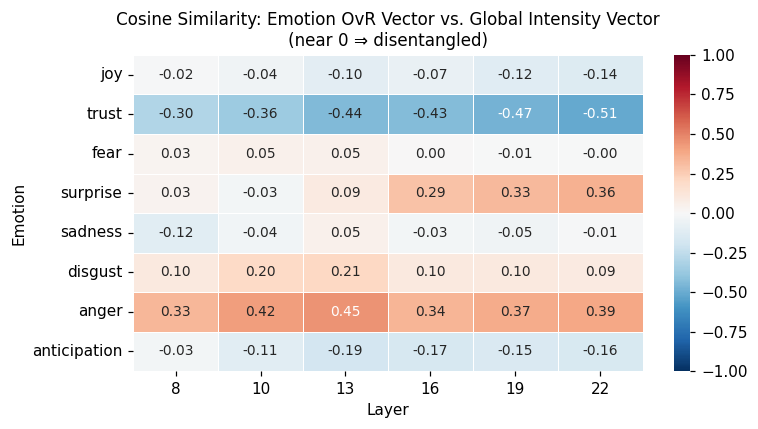

                  8       10      13      16      19      22
emotion                                                     
joy          -0.0152 -0.0430 -0.1031 -0.0738 -0.1220 -0.1351
trust        -0.2987 -0.3600 -0.4426 -0.4324 -0.4714 -0.5141
fear          0.0268  0.0487  0.0519  0.0017 -0.0078 -0.0032
surprise      0.0339 -0.0290  0.0863  0.2942  0.3274  0.3579
sadness      -0.1167 -0.0377  0.0512 -0.0291 -0.0458 -0.0139
disgust       0.0972  0.2010  0.2101  0.0952  0.0974  0.0921
anger         0.3345  0.4208  0.4510  0.3371  0.3680  0.3870
anticipation -0.0294 -0.1149 -0.1869 -0.1672 -0.1496 -0.1581


In [21]:
# cosim_ei[e, li] = cos(v_emotion[e, li], v_int[li])
cosim_ei = np.zeros((N_EMO, N_LAYERS))
for li in range(N_LAYERS):
    v_int = global_int_vec[li].astype(np.float64)
    v_int = v_int / (np.linalg.norm(v_int) + 1e-10)
    for ei in range(N_EMO):
        v_emo = emo_ovr[ei, li].astype(np.float64)
        v_emo = v_emo / (np.linalg.norm(v_emo) + 1e-10)
        cosim_ei[ei, li] = float(v_emo @ v_int)

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(6, N_LAYERS * 1.2), 4))
sns.heatmap(cosim_ei,
            xticklabels=LAYER_INDICES, yticklabels=EMOTION_ORDER,
            vmin=-1, vmax=1, cmap="RdBu_r",
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.5, ax=ax)
ax.set_xlabel("Layer"); ax.set_ylabel("Emotion")
ax.set_title("Cosine Similarity: Emotion OvR Vector vs. Global Intensity Vector\n"
             "(near 0 ⇒ disentangled)", fontsize=11)
plt.tight_layout()
fig.savefig(OUT_DIR / "emotion_vs_intensity_disentanglement.png", bbox_inches="tight")
plt.show()

# Save CSV
disent_df = pd.DataFrame(cosim_ei, index=EMOTION_ORDER, columns=LAYER_INDICES)
disent_df.index.name = "emotion"
disent_df.to_csv(OUT_DIR / "emotion_vs_intensity_cosim.csv")
print(disent_df.round(4).to_string())

## 8. Within-Source-Mean-Subtracted Analyses

Subtract within-source means to remove source-text semantic content.

- **Emotion delta:** $h^{\Delta}_{n,e,i,l} = h_{n,e,i,l} - \frac{1}{N_{\text{int}}} \sum_i h_{n,e,i,l}$ *(removes per-source-emotion baseline)*  
  Then reproduce emotion probes.

- **Intensity delta:** $h^{\Delta}_{n,e,i,l} = h_{n,e,i,l} - \frac{1}{N_{\text{emo}}} \sum_e h_{n,e,i,l}$ *(removes per-source-intensity baseline)*  
  Then reproduce intensity probes and intensity-direction analysis.

In [22]:
# ── Emotion delta ─────────────────────────────────────────────────────────────
# h_delta[n,e,i,l,:] = act[n,e,i,l,:] - mean_over_e(act[n,:,i,l,:])
# Build flat X_layers_emo_delta on disk (memmap) to avoid OOM
_mmap_emo_delta_path = OUT_DIR / "_X_emo_delta_tmp.mmap"
X_layers_emo_delta = np.memmap(str(_mmap_emo_delta_path), dtype=np.float32, mode="w+",
                                shape=(N_LAYERS, n_samples, D))

idx = 0
for n in range(N):
    src = act[n].astype(np.float32)                   # (N_EMO, N_INT, N_LAYERS, D)
    src_delta = src - src.mean(axis=0, keepdims=True) # subtract mean over emotion axis
    for ei in range(N_EMO):
        for ii in range(N_INT):
            X_layers_emo_delta[:, idx, :] = src_delta[ei, ii]
            idx += 1

X_layers_emo_delta.flush()

print("Emotion probes on mean-subtracted activations (emotion axis removed):")
emo_probes_delta = {}
for li in range(N_LAYERS):
    emo_probes_delta[li] = run_probe(X_layers_emo_delta[li], y_emotion, groups)
    r = emo_probes_delta[li]
    print(f"  Layer {LAYER_INDICES[li]:>2}  acc={r['acc']:.3f}  bal_acc={r['bal_acc']:.3f}")
    gc.collect()


Emotion probes on mean-subtracted activations (emotion axis removed):
  Layer  8  acc=0.881  bal_acc=0.883
  Layer 10  acc=0.868  bal_acc=0.869
  Layer 13  acc=0.877  bal_acc=0.878
  Layer 16  acc=0.866  bal_acc=0.867
  Layer 19  acc=0.844  bal_acc=0.846
  Layer 22  acc=0.821  bal_acc=0.823


In [23]:
# ── Intensity delta ───────────────────────────────────────────────────────────
# h_delta[n,e,i,l,:] = act[n,e,i,l,:] - mean_over_i(act[n,e,:,l,:])
# Build flat X_layers_int_delta on disk (memmap) to avoid OOM
_mmap_int_delta_path = OUT_DIR / "_X_int_delta_tmp.mmap"
X_layers_int_delta = np.memmap(str(_mmap_int_delta_path), dtype=np.float32, mode="w+",
                                shape=(N_LAYERS, n_samples, D))

# Also accumulate proto_int_delta for later use in cell 20027852
proto_int_delta_sum = np.zeros((N_EMO, N_INT, N_LAYERS, D), dtype=np.float64)

idx = 0
for n in range(N):
    src = act[n].astype(np.float32)                   # (N_EMO, N_INT, N_LAYERS, D)
    src_delta = src - src.mean(axis=1, keepdims=True) # subtract mean over intensity axis
    proto_int_delta_sum += src_delta.astype(np.float64)
    for ei in range(N_EMO):
        for ii in range(N_INT):
            X_layers_int_delta[:, idx, :] = src_delta[ei, ii]
            idx += 1

X_layers_int_delta.flush()
proto_int_delta = (proto_int_delta_sum / N).astype(np.float32)
del proto_int_delta_sum

# Also keep act_int_delta accessible for cell 20027852 (reuse proto_int_delta)
# act_int_delta is not stored in RAM; proto_int_delta serves as its mean.

print("Intensity probes on mean-subtracted activations (intensity axis removed):")
int_probes_delta = {}
for li in range(N_LAYERS):
    int_probes_delta[li] = run_probe(X_layers_int_delta[li], y_intensity, groups)
    r = int_probes_delta[li]
    print(f"  Layer {LAYER_INDICES[li]:>2}  acc={r['acc']:.3f}  bal_acc={r['bal_acc']:.3f}")
    gc.collect()


Intensity probes on mean-subtracted activations (intensity axis removed):
  Layer  8  acc=0.726  bal_acc=0.723
  Layer 10  acc=0.714  bal_acc=0.712
  Layer 13  acc=0.729  bal_acc=0.727
  Layer 16  acc=0.719  bal_acc=0.717
  Layer 19  acc=0.707  bal_acc=0.705
  Layer 22  acc=0.694  bal_acc=0.692


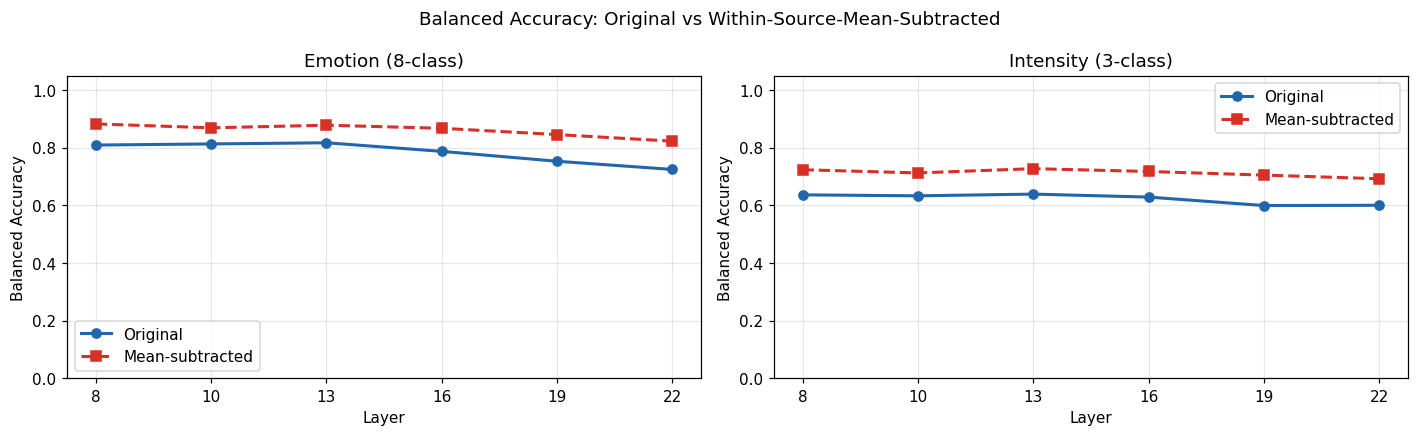

In [24]:
# ── Comparison plot: original vs mean-subtracted ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, orig, delta, title in [
    (axes[0], emo_probes, emo_probes_delta, "Emotion (8-class)"),
    (axes[1], int_probes, int_probes_delta, "Intensity (3-class)"),
]:
    orig_bals  = [orig[li]["bal_acc"]  for li in range(N_LAYERS)]
    delta_bals = [delta[li]["bal_acc"] for li in range(N_LAYERS)]
    ax.plot(layer_labels, orig_bals,  "o-",  label="Original",      color="#2166ac", linewidth=2)
    ax.plot(layer_labels, delta_bals, "s--", label="Mean-subtracted", color="#d73027", linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Layer"); ax.set_ylabel("Balanced Accuracy")
    ax.set_ylim(0, 1.05)
    ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle("Balanced Accuracy: Original vs Within-Source-Mean-Subtracted", fontsize=12)
plt.tight_layout()
fig.savefig(OUT_DIR / "probe_original_vs_mean_subtracted.png", bbox_inches="tight")
plt.show()

In [25]:
# ── Intensity direction analysis on mean-subtracted activations ───────────────
# proto_int_delta was computed in the previous cell (mean over N of act_int_delta)
int_dirs_delta  = (proto_int_delta[:, HIGH_IDX, :, :] -
                   proto_int_delta[:, LOW_IDX,  :, :])   # (N_EMO, N_LAYERS, D)

mean_offdiag_delta = []
for li in range(N_LAYERS):
    D_vecs = int_dirs_delta[:, li, :].astype(np.float64)
    CS = cosine_sim_matrix(D_vecs)
    mask_upper = np.triu(np.ones_like(CS, dtype=bool), k=1)
    mean_offdiag_delta.append(CS[mask_upper].mean())

print("Mean off-diagonal cosine similarity of intensity dirs (mean-subtracted):")
for li, mu in enumerate(mean_offdiag_delta):
    print(f"  Layer {LAYER_INDICES[li]:>2}: {mu:.4f}  (original: {mean_off_diag[li]:.4f})")


Mean off-diagonal cosine similarity of intensity dirs (mean-subtracted):
  Layer  8: 0.6617  (original: 0.6617)
  Layer 10: 0.7008  (original: 0.7008)
  Layer 13: 0.7106  (original: 0.7106)
  Layer 16: 0.6348  (original: 0.6348)
  Layer 19: 0.6343  (original: 0.6343)
  Layer 22: 0.6200  (original: 0.6200)


## 9. Summary

Compile final findings and write to a CSV.

In [26]:
# ── Collect results ───────────────────────────────────────────────────────────
best_emo_li_final  = max(emo_probes, key=lambda li: emo_probes[li]["bal_acc"])
best_int_li_final  = max(int_probes, key=lambda li: int_probes[li]["bal_acc"])
best_emo_layer     = LAYER_INDICES[best_emo_li_final]
best_int_layer     = LAYER_INDICES[best_int_li_final]

best_emo_bal  = emo_probes[best_emo_li_final]["bal_acc"]
best_int_bal  = int_probes[best_int_li_final]["bal_acc"]

max_shared_int = max(mean_off_diag)
best_shared_li = mean_off_diag.index(max_shared_int)
best_shared_layer = LAYER_INDICES[best_shared_li]

# Monotonicity: majority vote across layers
monotone_count = sum(
    mean_proj[LOW_IDX, li] < mean_proj[MED_IDX, li] < mean_proj[HIGH_IDX, li]
    for li in range(N_LAYERS)
)

# Disentanglement: mean absolute cosine similarity
mean_abs_disent = np.abs(cosim_ei).mean()

# ── Print summary ─────────────────────────────────────────────────────────────
summary_text = f"""
============================================================
  RESIDUAL STREAM ANALYSIS — SUMMARY
============================================================

Best layer for emotion decoding : Layer {best_emo_layer}
  Balanced accuracy             : {best_emo_bal:.3f}

Best layer for intensity decoding: Layer {best_int_layer}
  Balanced accuracy              : {best_int_bal:.3f}

Shared intensity axis (max mean off-diag cosine sim): {max_shared_int:.3f}
  Achieved at layer             : {best_shared_layer}
  Interpretation                : {'strong' if max_shared_int > 0.5 else 'moderate' if max_shared_int > 0.2 else 'weak'} shared axis

Monotonicity of intensity projections:
  low < medium < high in {monotone_count}/{N_LAYERS} layers
  {'→ Monotonic ordering confirmed' if monotone_count == N_LAYERS else f'→ Partial ordering ({monotone_count}/{N_LAYERS} layers)'}

Emotion–intensity disentanglement:
  Mean |cosine| (emotion vs. intensity): {mean_abs_disent:.3f}
  Interpretation: {'disentangled (near-orthogonal)' if mean_abs_disent < 0.2 else 'some alignment' if mean_abs_disent < 0.5 else 'entangled'}

Recommended layers for CAA steering:
  Emotion    : Layer {best_emo_layer}
  Intensity  : Layer {best_int_layer}
  Shared axis: Layer {best_shared_layer}
============================================================
"""
print(summary_text)

# Save as text
with open(OUT_DIR / "summary.txt", "w") as fh:
    fh.write(summary_text)

# Save key metrics as CSV
summary_df = pd.DataFrame([
    {"metric": "best_layer_emotion",         "value": best_emo_layer},
    {"metric": "best_balanced_acc_emotion",  "value": round(best_emo_bal, 4)},
    {"metric": "best_layer_intensity",        "value": best_int_layer},
    {"metric": "best_balanced_acc_intensity", "value": round(best_int_bal, 4)},
    {"metric": "max_shared_intensity_cosim",  "value": round(max_shared_int, 4)},
    {"metric": "best_layer_shared_intensity", "value": best_shared_layer},
    {"metric": "monotone_layers_count",       "value": monotone_count},
    {"metric": "mean_abs_disent_cosim",       "value": round(mean_abs_disent, 4)},
])
summary_df.to_csv(OUT_DIR / "summary_metrics.csv", index=False)
print("All outputs saved to:", OUT_DIR.resolve())


  RESIDUAL STREAM ANALYSIS — SUMMARY

Best layer for emotion decoding : Layer 13
  Balanced accuracy             : 0.817

Best layer for intensity decoding: Layer 13
  Balanced accuracy              : 0.639

Shared intensity axis (max mean off-diag cosine sim): 0.711
  Achieved at layer             : 13
  Interpretation                : strong shared axis

Monotonicity of intensity projections:
  low < medium < high in 6/6 layers
  → Monotonic ordering confirmed

Emotion–intensity disentanglement:
  Mean |cosine| (emotion vs. intensity): 0.177
  Interpretation: disentangled (near-orthogonal)

Recommended layers for CAA steering:
  Emotion    : Layer 13
  Intensity  : Layer 13
  Shared axis: Layer 13

All outputs saved to: /home/maplesugano/proj/EmotionEngine_v2/analysis/emotion_intensity
